In [1]:
import tensorflow as tf
# Create a tensor
a = tf.constant([1,2,3])
b = tf.constant([[1],[3]])
c = tf.constant(5)
print(b)

tf.Tensor(
[[1]
 [3]], shape=(2, 1), dtype=int32)


In [3]:
#tf.Variable() – Mutable tensor (for weights)
w = tf.Variable([[1.0, 2.0]])
w.assign([[3.0, 4.0]])  # Update value


<tf.Variable 'UnreadVariable' shape=(1, 2) dtype=float32, numpy=array([[3., 4.]], dtype=float32)>

In [4]:
#math operations
x = tf.constant([1.0,2.0])
y = tf.constant([3.0,4.0])
print(x+y)
print(x*y)

tf.Tensor([4. 6.], shape=(2,), dtype=float32)
tf.Tensor([3. 8.], shape=(2,), dtype=float32)


In [5]:
x = tf.constant([1.0, 2.0])
y = tf.constant([3.0, 4.0])

add = tf.add(x, y)           # [4.0, 6.0]
mul = tf.multiply(x, y)      # [3.0, 8.0]
square = tf.square(x)        # [1.0, 4.0]

In [6]:
#shape and reshape
t = tf.ones((2, 3))          # Shape: (2, 3)
reshaped = tf.reshape(t, (3, 2))
print(t.shape)               # (2, 3)
print(tf.size(t))            # 6

(2, 3)
tf.Tensor(6, shape=(), dtype=int32)


In [7]:
reshaped

<tf.Tensor: shape=(3, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.],
       [1., 1.]], dtype=float32)>

##Building Models

In [10]:
#Sequential API (Simple, linear stack)
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Flatten

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(10,activation = 'softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
#Functional API (Flexible, complex models)
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.models import Model

inputs = Input(shape=(28, 28)) # Change input shape to match the image dimensions
x = Flatten()(inputs) # Add a Flatten layer to reshape the input
x = Dense(128, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)

In [12]:
#Compile the Model
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

In [13]:
#Data Handling & Preprocessing
(x_train,y_train),(x_test,y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print(x_train.shape)
print(y_train.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)


In [14]:
#Create Dataset Pipeline (tf.data)
train_data = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_data = train_data.shuffle(1000).batch(32).prefetch(1)


In [20]:
# Compile the Model
model.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics = ['accuracy'])

# Train the Model
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1  # 1 = progress bar, 0 = silent
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8742 - loss: 0.4471 - val_accuracy: 0.9561 - val_loss: 0.1518
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9654 - loss: 0.1209 - val_accuracy: 0.9710 - val_loss: 0.0998
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - accuracy: 0.9767 - loss: 0.0765 - val_accuracy: 0.9733 - val_loss: 0.0878
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9821 - loss: 0.0571 - val_accuracy: 0.9753 - val_loss: 0.0777
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9863 - loss: 0.0447 - val_accuracy: 0.9762 - val_loss: 0.0742


In [21]:
#Evaluate & Predict
test_loss ,test_acc = model.evaluate(x_test,y_test,verbose =0)
print(f"Test Accuracy: {test_acc}")

Test Accuracy: 0.9761999845504761


In [22]:
#predict
predictions = model.predict(x_test[:5])     # Predict first 5 images
predicted_classes = tf.argmax(predictions, axis=1)  # Get class index
print(predicted_classes.numpy())            # [7 2 1 0 4]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
[7 2 1 0 4]


In [23]:
predicted_classes

<tf.Tensor: shape=(5,), dtype=int64, numpy=array([7, 2, 1, 0, 4])>

In [26]:
#Save & Load Model
model.save('my_model.h5')           # HDF5 format
# OR
model.save('my_model.keras')              # SavedModel format (default)

In [27]:
loaded_model = tf.keras.models.load_model('my_model.h5')


In [28]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

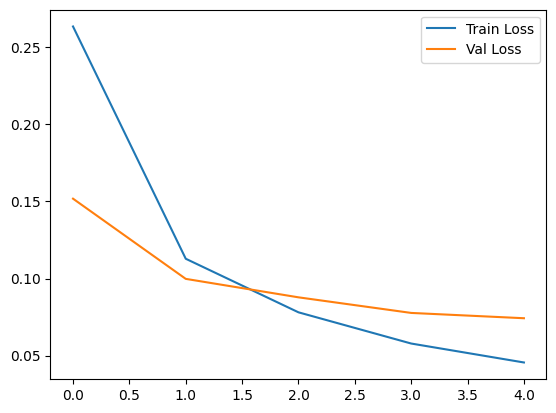

In [30]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

In [31]:
#Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience = 3,restore_best_weights = True)
#

In [32]:
#Save Best Model
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [34]:
model.fit(x_train, y_train, callbacks=[early_stop, checkpoint])

1866/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9904 - loss: 0.0315

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:302: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9904 - loss: 0.0316
